# Decision Tree and Random Forest classifie

Decision Tree : Root Node, Leave Node , it is tree model
: Decision tree is a machine learning algorithm that makes decisions like a flowchart or trr structure.

it asks multiple question and finally reaches a decision.

Random forest : Advance of decision tree. this is assemble model

ex: T1, T2,T3



## Conceptual Interview Questions

### Decision Trees

1.  **What is a Decision Tree?** How does it work for classification?
2.  **Explain the key components** of a Decision Tree: root node, internal nodes, leaf nodes, and branches.
3.  **What are Gini impurity and Entropy?** How are they used in Decision Trees?
4.  **How does a Decision Tree handle numerical and categorical features?**
5.  **What is pruning in Decision Trees?** Why is it important, and what are the types of pruning?
6.  **What are the advantages and disadvantages** of Decision Trees?
7.  **How do you prevent overfitting** in Decision Trees?

### Random Forests

1.  **What is a Random Forest?** How does it differ from a single Decision Tree?
2.  **Explain the concept of 'ensemble learning'** and how Random Forests utilize it.
3.  **What are the two main sources of randomness** in a Random Forest algorithm?
4.  **How does a Random Forest make a prediction** (for classification)?
5.  **What are the advantages and disadvantages** of Random Forests?
6.  **When would you choose a Random Forest over a Decision Tree?**
7.  **What are Out-of-Bag (OOB) error estimates?** How are they useful?
8.  **How can you determine feature importance** using a Random Forest?

### Comparing Models

1.  **When would you prefer a simple Decision Tree over a Random Forest?**
2.  **How do Decision Trees and Random Forests handle bias-variance trade-off?**
3.  **Discuss the interpretability** of Decision Trees versus Random Forests.

## Coding Implementation

Let's implement a Decision Tree and a Random Forest classifier using `scikit-learn` and compare their performance on a sample dataset.

In [6]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

### 1. Load and Prepare Data

We'll use the Iris dataset, a classic dataset for classification tasks.

In [7]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for better inspection (optional)
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target_names[y]
display(df.head())

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2. Decision Tree Classifier

Train a Decision Tree model and evaluate its performance.

In [8]:
# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dtc.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=iris.target_names))

Decision Tree Classifier Performance:
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### 3. Random Forest Classifier

Train a Random Forest model and evaluate its performance. Notice how it often achieves higher accuracy due to its ensemble nature.

In [9]:
# Initialize the Random Forest Classifier
# n_estimators is the number of trees in the forest
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rfc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rfc.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

Random Forest Classifier Performance:
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### 4. Visualizing a Decision Tree (Optional)

One of the advantages of Decision Trees is their interpretability. We can visualize a trained tree.

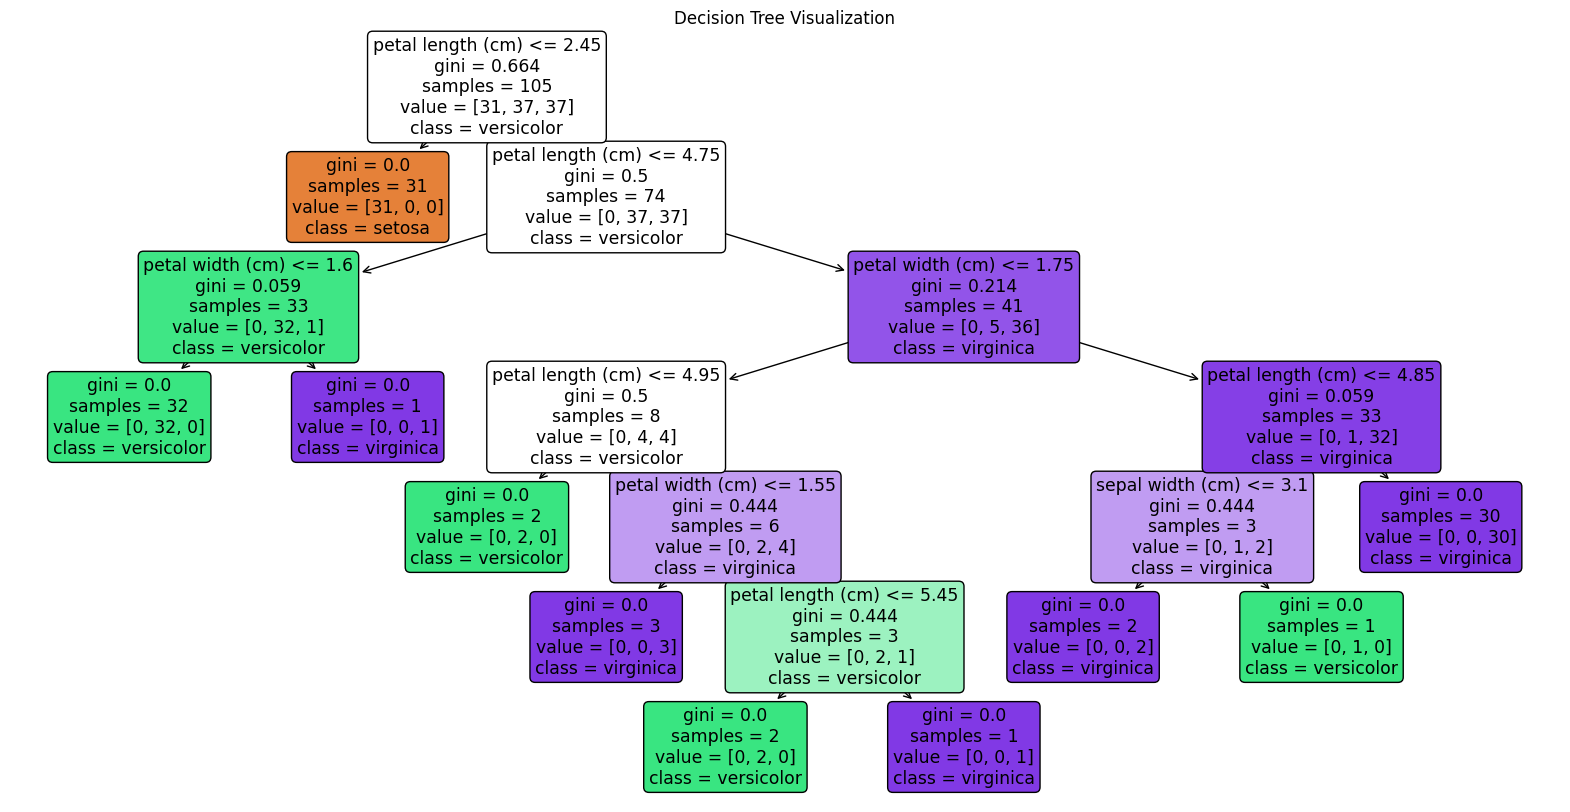

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

### 5. Feature Importance (Random Forest)

Random Forests can also provide insights into feature importance, indicating which features contributed most to the model's predictions.

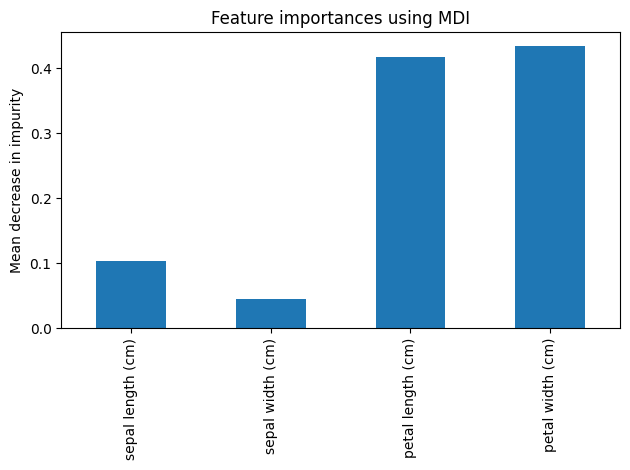

In [11]:
importances = rfc.feature_importances_
feature_names = iris.feature_names

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

## Detailed Comparison: Decision Trees vs. Random Forests

Having explored both Decision Trees and Random Forests conceptually and through code, let's delve deeper into their comparison, addressing some of the questions we outlined earlier.

### 1. Bias-Variance Trade-off

*   **Decision Trees:** A single, unpruned Decision Tree is a **high-variance, low-bias** model. It tends to overfit the training data, capturing noise and specific patterns in the training set rather than the underlying distribution. This leads to excellent performance on training data but poor generalization to unseen data.
*   **Random Forests:** Random Forests, being an ensemble of Decision Trees, effectively address the high variance issue. By aggregating predictions from multiple trees trained on bootstrapped samples and random subsets of features, they **reduce variance significantly**. While the bias might be slightly higher than a single overfit Decision Tree (as individual trees might be weaker), the overall reduction in variance usually leads to a much better bias-variance trade-off and improved generalization performance.

### 2. Interpretability

*   **Decision Trees:** These are generally considered **highly interpretable**, especially when they are not too deep. You can visualize the tree structure (as we did) and literally follow the decision rules from the root to a leaf node to understand how a prediction is made. This makes them valuable for explaining predictions to non-technical stakeholders.
*   **Random Forests:** While powerful, Random Forests are often considered **less interpretable** than single Decision Trees. They are a 'black box' model because they consist of many trees, and it's practically impossible to inspect every decision path of every tree. However, tools like feature importance (which we demonstrated) can provide insights into which features are most influential in the model's overall prediction, offering a degree of interpretability.

### 3. Overfitting

*   **Decision Trees:** Prone to overfitting, especially when allowed to grow to full depth without regularization. Techniques like pruning (pre-pruning or post-pruning), setting `max_depth`, `min_samples_split`, or `min_samples_leaf` are used to mitigate this.
*   **Random Forests:** Inherently more robust to overfitting than single Decision Trees due to the averaging effect of multiple diverse trees. The randomness introduced through bagging and feature sampling helps prevent any single tree from overfitting too much to specific training data patterns, and the aggregation smooths out the noise.

### 4. When to Prefer One Over the Other

*   **Prefer a simple Decision Tree when:**
    *   **Interpretability is paramount:** You need to clearly explain the decision logic to stakeholders.
    *   **The dataset is small and simple:** An ensemble might be overkill, and a single tree could perform adequately.
    *   **Baseline model:** It can serve as a quick and easily understandable baseline for comparison.

*   **Prefer a Random Forest when:**
    *   **High accuracy and robust performance are critical:** Random Forests generally outperform single Decision Trees in terms of predictive accuracy across a wide range of tasks.
    *   **Overfitting is a significant concern:** Their ensemble nature makes them less susceptible to overfitting.
    *   **Feature importance is needed:** They provide a reliable way to gauge the relative importance of input features.
    *   **You have a large or complex dataset:** The ensemble approach can handle complexity and noise effectively.

### Summary of Key Differences

| Feature           | Decision Tree                               | Random Forest                                     |
| :---------------- | :------------------------------------------ | :------------------------------------------------ |
| **Model Type**    | Single model                                | Ensemble of Decision Trees                        |
| **Bias**          | Low (can capture complex patterns)          | Slightly higher than single DT (due to averaging) |
| **Variance**      | High (prone to overfitting)                 | Low (reduced by averaging diverse trees)          |
| **Interpretability** | High (easy to visualize and understand rules) | Low (black-box, but feature importance helps)     |
| **Performance**   | Good, but often overfits                    | Generally excellent and robust                    |
| **Overfitting**   | High risk                                   | Low risk                                          |
| **Training Time** | Faster                                      | Slower (trains multiple trees)                    |
| **Prediction Time** | Faster                                      | Slower (aggregates multiple predictions)          |

## Answers to Conceptual Interview Questions

### Decision Trees

1.  **What is a Decision Tree? How does it work for classification?**
    *   A Decision Tree is a non-parametric supervised learning algorithm that is used for both classification and regression tasks. It works by recursively partitioning the data based on feature values, creating a tree-like model of decisions.
    *   For classification, it starts at the root node and evaluates a feature-based condition. Based on the outcome, it moves down to a child node. This process continues until it reaches a leaf node, which represents the predicted class label for the input data.

2.  **Explain the key components of a Decision Tree: root node, internal nodes, leaf nodes, and branches.**
    *   **Root Node:** The topmost node in the tree, representing the initial decision or entire dataset. It has no incoming branches.
    *   **Internal Nodes (Decision Nodes):** Nodes that represent a feature-based decision or test. They have one incoming branch and two or more outgoing branches, each leading to a different outcome of the test.
    *   **Leaf Nodes (Terminal Nodes):** Nodes at the end of the branches that do not split further. They represent the final decision or class label for classification (or a predicted value for regression).
    *   **Branches:** The connections between nodes, representing the outcome of a decision or condition.

3.  **What are Gini impurity and Entropy? How are they used in Decision Trees?**
    *   **Gini Impurity:** A measure of how often a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset. A Gini impurity of 0 means all elements belong to a single class (pure node).
    *   **Entropy:** A measure of the randomness or disorder in a set of examples. An entropy of 0 means the set is completely homogeneous (pure node), while higher entropy indicates more disorder.
    *   **Usage:** Both Gini impurity and Entropy (or Information Gain, which is based on entropy) are used as criteria to determine the 'best' split at each node. The algorithm chooses the split that results in the greatest reduction in impurity (for Gini) or the highest information gain (for Entropy), aiming to create more homogeneous child nodes.

4.  **How does a Decision Tree handle numerical and categorical features?**
    *   **Categorical Features:** For categorical features, the tree typically splits based on the categories. If there are a few categories, it might create a branch for each category or group categories into binary splits.
    *   **Numerical Features:** For numerical features, the tree finds a 'threshold' value. It creates a binary split: one branch for samples where the feature value is less than or equal to the threshold, and another for samples where it's greater than the threshold. This process is repeated for each numerical feature to find the optimal split point.

5.  **What is pruning in Decision Trees? Why is it important, and what are the types of pruning?**
    *   **Pruning:** The process of reducing the size of the Decision Tree by removing sections of the tree that provide little power to classify instances. It's crucial for improving the tree's generalization ability.
    *   **Importance:** Unpruned Decision Trees tend to overfit the training data, capturing noise and specific patterns rather than general rules. Pruning helps to mitigate overfitting by simplifying the tree and reducing its complexity.
    *   **Types:**
        *   **Pre-pruning (Early Stopping):** Stopping the tree growth early before it becomes a fully grown tree. This can be done by setting parameters like `max_depth`, `min_samples_split`, or `min_samples_leaf` in `scikit-learn`.
        *   **Post-pruning:** Growing the full tree first and then removing branches that do not contribute significantly to the model's performance (e.g., using cost-complexity pruning or reduced error pruning).

6.  **What are the advantages and disadvantages of Decision Trees?**
    *   **Advantages:**
        *   Easy to understand and interpret (white-box model).
        *   Can handle both numerical and categorical data.
        *   Requires little data preparation (no need for feature scaling or normalization).
        *   Can model non-linear relationships.
    *   **Disadvantages:**
        *   Prone to overfitting, especially with complex trees.
        *   Can be unstable: small changes in the data can lead to a completely different tree structure.
        *   Can create biased trees if some classes dominate.
        *   Optimal decision tree construction is an NP-hard problem; practical algorithms use heuristics.

7.  **How do you prevent overfitting in Decision Trees?**
    *   **Pruning:** As discussed above, both pre-pruning (e.g., setting `max_depth`, `min_samples_split`, `min_samples_leaf`) and post-pruning techniques.
    *   **Limiting tree depth:** Restricting the maximum depth of the tree (`max_depth`).
    *   **Minimum samples per leaf:** Ensuring that each leaf node has a minimum number of samples (`min_samples_leaf`).
    *   **Minimum samples for a split:** Requiring a minimum number of samples in a node before a split is attempted (`min_samples_split`).
    *   **Maximum features to consider for a split:** Randomly selecting a subset of features to consider at each split, which can introduce randomness and prevent a single strong feature from dominating the tree (more common in Random Forests but can be applied to single trees).

### Random Forests

1.  **What is a Random Forest? How does it differ from a single Decision Tree?**
    *   A Random Forest is an ensemble learning method that operates by constructing a multitude of Decision Trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.
    *   **Difference from a single Decision Tree:** Instead of building one deep, potentially overfit tree, a Random Forest builds many relatively 'weak' trees and combines their predictions to make a more robust and accurate overall prediction. It explicitly addresses the high variance of single Decision Trees.

2.  **Explain the concept of 'ensemble learning' and how Random Forests utilize it.**
    *   **Ensemble Learning:** A technique where multiple individual models (often called 'weak learners' or 'base models') are trained and their predictions are combined to produce a stronger, more accurate predictive model than any single model alone.
    *   **Random Forests' Utilization:** Random Forests use a specific type of ensemble learning called **Bagging (Bootstrap Aggregating)**. It creates multiple Decision Trees by:
        *   **Bootstrapping:** Each tree is trained on a random sample of the training data with replacement (bootstrap sample).
        *   **Feature Randomness:** At each split in a tree, only a random subset of features is considered for finding the best split. This decorrelates the trees.
        The predictions from all individual trees are then aggregated (e.g., majority vote for classification, averaging for regression).

3.  **What are the two main sources of randomness in a Random Forest algorithm?**
    *   **Bootstrapping (Row Sampling with Replacement):** Each tree in the forest is trained on a different random subset of the training data, sampled with replacement. This ensures that each tree sees a slightly different view of the data.
    *   **Feature Randomness (Column Subsampling):** At each node split during the construction of a Decision Tree, only a random subset of the total features is considered for finding the best split. This helps to decorrelate the trees and prevent a single strong feature from dominating all trees.

4.  **How does a Random Forest make a prediction (for classification)?**
    *   For a new data point, each individual Decision Tree in the forest makes its own prediction (i.e., classifies the data point into a class).
    *   These individual predictions are then collected.
    *   For classification, the Random Forest combines these predictions by taking a **majority vote**. The class that receives the most votes from the individual trees is chosen as the final prediction for the Random Forest.

5.  **What are the advantages and disadvantages of Random Forests?**
    *   **Advantages:**
        *   **High Accuracy:** Often produces high accuracy and robust predictions due to ensemble learning.
        *   **Reduced Overfitting:** Less prone to overfitting than a single Decision Tree.
        *   **Handles High Dimensionality:** Can handle datasets with a large number of features.
        *   **Feature Importance:** Provides a good estimate of feature importance.
        *   **Handles Missing Values:** Can work well even with a significant amount of missing data (though not directly implemented in `scikit-learn` without preprocessing).
    *   **Disadvantages:**
        *   **Less Interpretable:** Considered a 'black box' model compared to a single Decision Tree.
        *   **Computationally Expensive:** Can be slower to train than a single Decision Tree, especially with a large number of trees.
        *   **More Complex:** Requires more computational resources for training and prediction.
        *   Might not perform well on very sparse datasets.

6.  **When would you choose a Random Forest over a Decision Tree?**
    *   **When high predictive accuracy is the priority:** Random Forests generally outperform single Decision Trees.
    *   **When overfitting is a major concern:** Random Forests are much more robust to overfitting.
    *   **When dealing with complex datasets with many features and potential noise:** The ensemble approach handles these well.
    *   **When you need reliable feature importance estimates.**

7.  **What are Out-of-Bag (OOB) error estimates? How are they useful?**
    *   **OOB Error Estimate:** In Random Forests, each tree is trained on a bootstrap sample, meaning approximately one-third of the original training data is left out for each tree (these are the 'out-of-bag' samples). The OOB error estimate is calculated by predicting the class of these OOB samples for each tree that did *not* use them in its training, and then aggregating these predictions.
    *   **Usefulness:** OOB error provides an unbiased estimate of the generalization error (test error) without the need for a separate validation set. This saves computational resources and can be particularly useful when data is scarce.

8.  **How can you determine feature importance using a Random Forest?**
    *   Random Forests provide a natural way to measure feature importance. The most common method is **Mean Decrease in Impurity (MDI)**, also known as Gini Importance (for Gini impurity-based trees) or Information Gain Importance (for entropy-based trees).
    *   It calculates the total reduction in the criterion (Gini impurity or entropy) brought about by splits over a given feature, averaged over all trees in the forest. Features that contribute more to reducing impurity across the trees are considered more important.
    *   Another method is **Permutation Importance**, which measures how much the model's performance decreases when a feature's values are randomly shuffled. This method is often preferred as it's less biased than MDI.

### Comparing Models

1.  **When would you prefer a simple Decision Tree over a Random Forest?**
    *   **High Interpretability is required:** If explaining the exact decision path is critical to stakeholders or for regulatory purposes.
    *   **Small, simple datasets:** For very straightforward problems, a single Decision Tree might be sufficient and computationally cheaper.
    *   **As a baseline model:** To quickly establish a baseline performance before moving to more complex models.
    *   **Resource constraints:** When computational resources or training time are severely limited, and accuracy is not the absolute top priority.

2.  **How do Decision Trees and Random Forests handle bias-variance trade-off?**
    *   **Decision Trees:** Tend to have **low bias** (can learn complex patterns well) but **high variance** (highly sensitive to training data, leading to overfitting). An unpruned tree will capture noise, resulting in poor generalization.
    *   **Random Forests:** Effectively manage the bias-variance trade-off. They maintain a relatively **low bias** (as individual trees can capture complexity) while significantly **reducing variance** through ensemble averaging and randomness. The aggregation of many diverse trees helps to smooth out the individual trees' high variance, leading to better generalization.

3.  **Discuss the interpretability of Decision Trees versus Random Forests.**
    *   **Decision Trees (High Interpretability):** Decision Trees are often called 'white-box' models. Their decision rules can be easily visualized and understood. You can follow a clear path from the root to a leaf node to see exactly why a particular prediction was made. This transparency is a major advantage for debugging, explaining predictions to non-technical audiences, and ensuring fairness.
    *   **Random Forests (Lower Interpretability, 'Black Box'):** Random Forests are considered less interpretable ('black-box' models). Because they consist of hundreds or thousands of individual Decision Trees, it's practically impossible to trace the decision path for a single prediction through all the trees. While you can get insights like feature importance, you lose the granular, step-by-step interpretability of a single tree. This can be a disadvantage in applications where model transparency is crucial (e.g., healthcare, finance).